In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [5]:
gdp = pd.read_excel("gdp_data.xls", skiprows=3)

gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Total natural resources rents (% of GDP),NY.GDP.TOTL.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.003344,0.002827,0.001885,0.001680,0.003037,0.002066,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Total natural resources rents (% of GDP),NY.GDP.TOTL.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.241550,7.921979,7.572946,6.743400,6.150652,10.330017,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Total natural resources rents (% of GDP),NY.GDP.TOTL.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.617410,0.702982,0.855264,0.682288,0.305978,0.428525,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Total natural resources rents (% of GDP),NY.GDP.TOTL.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.360027,8.878331,10.002526,8.626806,5.917264,9.734380,NaN,NaN,NaN,NaN
4,Angola,AGO,Total natural resources rents (% of GDP),NY.GDP.TOTL.RT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,20.885120,25.950330,32.045406,28.897859,20.247665,29.967435,NaN,NaN,NaN,NaN


In [6]:
gdp = pd.read_excel("gdp_data.xls", skiprows=3)

resources = pd.read_excel("natural_resources.xls", skiprows=3)

In [7]:
print("GDP Dataset:")
print(gdp.head())

print("\nNatural Resources Dataset:")
print(resources.head())

GDP Dataset:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                             Indicator Name     Indicator Code  1960  1961  \
0  Total natural resources rents (% of GDP)  NY.GDP.TOTL.RT.ZS   NaN   NaN   
1  Total natural resources rents (% of GDP)  NY.GDP.TOTL.RT.ZS   NaN   NaN   
2  Total natural resources rents (% of GDP)  NY.GDP.TOTL.RT.ZS   NaN   NaN   
3  Total natural resources rents (% of GDP)  NY.GDP.TOTL.RT.ZS   NaN   NaN   
4  Total natural resources rents (% of GDP)  NY.GDP.TOTL.RT.ZS   NaN   NaN   

   1962  1963  1964  1965  ...       2016       2017       2018       2019  \
0   NaN   NaN   NaN   NaN  ...   0.003344   0.002827   0.001885   0.001680   
1   NaN   NaN   NaN   NaN  ...   7.241550   7.921979   7.572946   6.743400   
2

In [8]:
gdp = pd.read_excel("gdp_data.xls", skiprows=3)

resources = pd.read_excel("natural_resources.xls", skiprows=3)

In [9]:
print(pd.read_excel("gdp_data.xls", skiprows=3)["Indicator Name"].iloc[0])
print(pd.read_excel("natural_resources.xls", skiprows=3)["Indicator Name"].iloc[0])

Total natural resources rents (% of GDP)
GDP (current US$)


In [10]:
resources = pd.read_excel("gdp_data.xls", skiprows=3)

gdp = pd.read_excel("natural_resources.xls", skiprows=3)

In [11]:
# Natural Resources dataset
resources = pd.read_excel("gdp_data.xls", skiprows=3)

# GDP dataset
gdp = pd.read_excel("natural_resources.xls", skiprows=3)

In [13]:
countries = [
    "United States",
    "China",
    "India",
    "Saudi Arabia",
    "Singapore"
]

gdp_5 = gdp[gdp["Country Name"].isin(countries)]
resources_5 = resources[resources["Country Name"].isin(countries)]

print("GDP:")
display(gdp_5[["Country Name", "2021"]])

print("\nNatural Resources:")
display(resources_5[["Country Name", "2021"]])

GDP:


,Country Name,2021
40,China,1.820170e+13
108,India,3.167271e+12
204,Saudi Arabia,9.826611e+11
207,Singapore,4.411109e+11
250,United States,2.372564e+13



Natural Resources:


,Country Name,2021
40,China,1.707565
108,India,3.159345
204,Saudi Arabia,25.565242
207,Singapore,0.000181
250,United States,1.279944


In [14]:
# Keep only the required columns
gdp_final = gdp_5[["Country Name", "2021"]].copy()
resources_final = resources_5[["Country Name", "2021"]].copy()

# Rename columns
gdp_final.columns = ["Country", "GDP_2021"]
resources_final.columns = ["Country", "Natural_Resources_%"]

# Merge both datasets
country_data = pd.merge(
    gdp_final,
    resources_final,
    on="Country"
)

# Show final table
country_data

,Country,GDP_2021,Natural_Resources_%
0,China,1.820170e+13,1.707565
1,India,3.167271e+12,3.159345
2,Saudi Arabia,9.826611e+11,25.565242
3,Singapore,4.411109e+11,0.000181
4,United States,2.372564e+13,1.279944


In [15]:
# Normalize GDP and Natural Resources to a 0-100 scale

country_data["GDP_Score"] = (
    country_data["GDP_2021"] / country_data["GDP_2021"].max()
) * 100

country_data["Resource_Score"] = (
    country_data["Natural_Resources_%"] /
    country_data["Natural_Resources_%"].max()
) * 100

# Create weighted Country Valuation Score
country_data["Country_Valuation_Score"] = (
    country_data["GDP_Score"] * 0.7 +
    country_data["Resource_Score"] * 0.3
)

# Round the scores
country_data = country_data.round(2)

country_data

,Country,GDP_2021,Natural_Resources_%,GDP_Score,Resource_Score,Country_Valuation_Score
0,China,1.820170e+13,1.71,76.72,6.68,55.71
1,India,3.167271e+12,3.16,13.35,12.36,13.05
2,Saudi Arabia,9.826611e+11,25.57,4.14,100.00,32.90
3,Singapore,4.411109e+11,0.00,1.86,0.00,1.30
4,United States,2.372564e+13,1.28,100.00,5.01,71.50


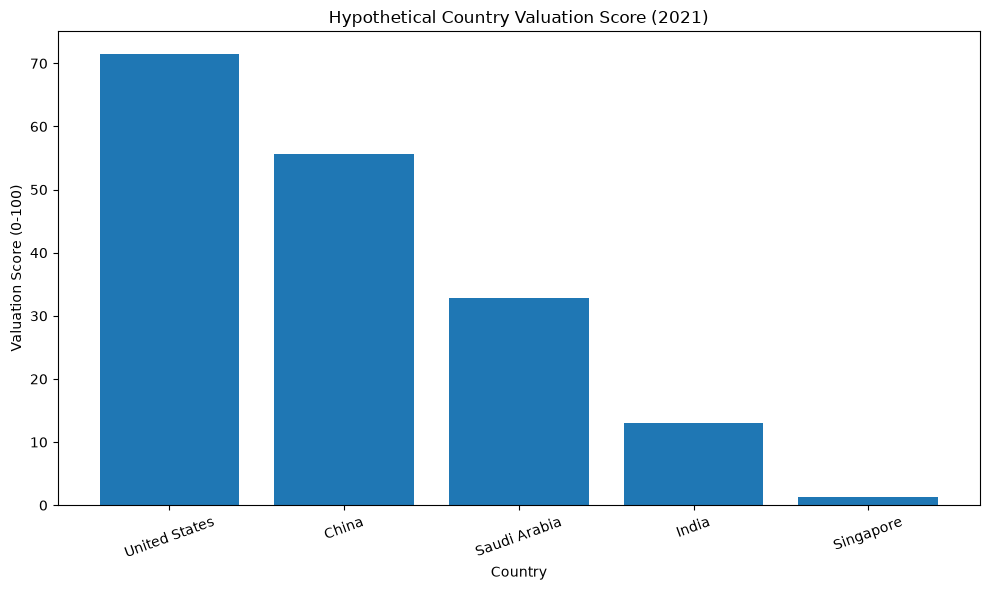

In [16]:
# Sort countries by valuation score
chart_data = country_data.sort_values(
    "Country_Valuation_Score",
    ascending=False
)

# Create bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    chart_data["Country"],
    chart_data["Country_Valuation_Score"]
)

plt.title("Hypothetical Country Valuation Score (2021)")
plt.xlabel("Country")
plt.ylabel("Valuation Score (0-100)")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [17]:
final_results = country_data[
    ["Country", "GDP_2021", "Natural_Resources_%", 
     "GDP_Score", "Resource_Score", "Country_Valuation_Score"]
].sort_values("Country_Valuation_Score", ascending=False)

final_results

,Country,GDP_2021,Natural_Resources_%,GDP_Score,Resource_Score,Country_Valuation_Score
4,United States,2.372564e+13,1.28,100.00,5.01,71.50
0,China,1.820170e+13,1.71,76.72,6.68,55.71
2,Saudi Arabia,9.826611e+11,25.57,4.14,100.00,32.90
1,India,3.167271e+12,3.16,13.35,12.36,13.05
3,Singapore,4.411109e+11,0.00,1.86,0.00,1.30


#### This analysis values countries hypothetically as if they were assets using two factors: economic size and natural resources. GDP was given a weight of 70%, while natural resource rents were given a weight of 30%. Based on 2021 World Bank data, the United States achieved the highest valuation score of 71.50, followed by China at 55.71. Saudi Arabia ranked third because of its very high natural resource value. India and Singapore received lower scores under this specific framework. The analysis shows that a country's hypothetical value depends significantly on the factors and weights selected. A more advanced model could additionally include human capital, infrastructure, strategic importance, and country risk.
